In [ ]:
import torch
from torch import nn
import torch.utils.data as data
from torch.utils.data.sampler import SubsetRandomSampler
import numpy as np
import math
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Paper5.zip to Paper5.zip


In [ ]:
!unzip Paper5.zip

Archive:  Paper5.zip
   creating: Paper/
  inflating: Paper/dataset_170.0.txt  
  inflating: Paper/dataset_170.1.txt  
  inflating: Paper/dataset_170.2.txt  
  inflating: Paper/dataset_170.3.txt  
  inflating: Paper/dataset_170.4.txt  
  inflating: Paper/dataset_170.5.txt  
  inflating: Paper/dataset_170.6.txt  
  inflating: Paper/dataset_170.7.txt  
  inflating: Paper/dataset_170.8.txt  
  inflating: Paper/dataset_170.9.txt  
  inflating: Paper/dataset_171.0.txt  
  inflating: Paper/dataset_171.1.txt  
  inflating: Paper/dataset_171.2.txt  
  inflating: Paper/dataset_171.3.txt  
  inflating: Paper/dataset_171.4.txt  
  inflating: Paper/dataset_171.5.txt  
  inflating: Paper/dataset_171.6.txt  
  inflating: Paper/dataset_171.7.txt  
  inflating: Paper/dataset_171.8.txt  
  inflating: Paper/dataset_171.9.txt  
  inflating: Paper/dataset_172.0.txt  
  inflating: Paper/dataset_172.1.txt  
  inflating: Paper/dataset_172.2.txt  
  inflating: Paper/dataset_172.3.txt  
  inflating: Paper/data

In [ ]:

#Device Agnostic code
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

#merging all datasets in random fashion so to get 1000 samples from each mass
dataset = []
for i in range(1700, 1801, 1):
    i = round(i*0.1,1)
    file = "Paper/dataset_" + str(i)+".txt"

    data = np.loadtxt(file)
    np.random.shuffle(data)
    if len(data) > 5000:
        data = data[:10000]

    dataset.append(data)

dataset = torch.tensor(np.concatenate(dataset, axis=0), dtype=torch.float32)




In [ ]:

raw_mins = [dataset[:, i].min().item() for i in range(4)]
raw_maxs = [dataset[:, i].max().item() for i in range(4)]

mask = torch.ones(len(dataset), dtype=bool)
for i in range(4):
    zetamin = dataset[:, i].min()
    zetamax = dataset[:, i].max()
    dataset[:, i] = torch.log10(dataset[:, i] / zetamin) / torch.log10(zetamax / zetamin)
    low  = torch.quantile(dataset[:, i], 0.005)
    high = torch.quantile(dataset[:, i], 0.995)
    mask &= ((dataset[:, i] >= low) & (dataset[:, i] <= high))

dataset = dataset[mask]

post_mins = [dataset[:, i].min().item() for i in range(5)]
post_maxs = [dataset[:, i].max().item() for i in range(5)]

for i in range(5):
    massmin = dataset[:, i].min()
    massmax = dataset[:, i].max()
    dataset[:, i] = (dataset[:, i] - massmin) / (massmax - massmin)

preprocessing_params = {
    'raw_mins':  raw_mins,   # before log transform
    'raw_maxs':  raw_maxs,
    'post_mins': post_mins,  # after excision, before final normalization
    'post_maxs': post_maxs,
}
torch.save(preprocessing_params, 'preprocessing_params.pt')
print("Saved preprocessing params:")
print(preprocessing_params)

Saved preprocessing params:
{'raw_mins': [8.857419797614341e-10, 3.382019997388852e-07, 4.690350010605471e-07, 1.0000100019169622e-06], 'raw_maxs': [0.3695479929447174, 0.7592570185661316, 0.8649129867553711, 0.0037726699374616146], 'post_mins': [0.3620184063911438, 0.19400495290756226, 0.21644943952560425, 0.0011997916735708714, 170.0], 'post_maxs': [0.931786298751831, 0.926906168460846, 0.9398249387741089, 0.6935781240463257, 180.0]}


In [ ]:
E_tilde = dataset[:,3]
print(f"E_tilde mean: {E_tilde.mean():.6f}")
print(f"E_tilde max:  {E_tilde.max():.6f}")
print(f"E_tilde min:  {E_tilde.min():.6f}")

E_tilde mean: 0.262192
E_tilde max:  1.000000
E_tilde min:  0.000000


In [ ]:
from torch.utils.data import DataLoader

#Creating training and testing datasets
batch_size = 4096
test_size = 0.1
num_samples = len(dataset)

test_no = int(test_size * num_samples)
train_no = len(dataset) - test_no

np.random.seed(42)
indices = np.arange(len(dataset))
np.random.shuffle(indices)

train_index, test_index = indices[:train_no], indices[train_no:train_no+test_no]

# define samplers for obtaining training and testing batches
train_sampler = SubsetRandomSampler(train_index)
test_sampler = SubsetRandomSampler(test_index)

train_load = DataLoader(dataset, batch_size = batch_size, sampler = train_sampler)
test_load = DataLoader(dataset, batch_size = batch_size, sampler = test_sampler)



In [ ]:

#Model
class DNN(nn.Module):
    def __init__(self,in_shape: int,hidden_units: int, out_shape: int, num_layers: int):
        #in_shape = 4; hidden_units = 256, out_shape = 1, num_layers = 7
        super().__init__()

        #Layers of calling
        self.convs = nn.ModuleList()
        self.convs.append(nn.Linear(in_shape, hidden_units))
        self.convs.append(nn.ReLU())
        for i in range(num_layers-2):
            self.convs.append(nn.Linear(hidden_units, hidden_units))
            self.convs.append(nn.ReLU())
        self.convs.append(nn.Linear(hidden_units, out_shape))

    def forward(self, x: torch.Tensor):
        for conv in self.convs:
            x = conv(x) #(32, 1)

        return x #ln(EEEC_phi)

In [ ]:

#loss_function
def loss_fn(y_true, ln_pred, model):

    N = len(y_true)
    lam = 50

    # Main term
    part1 = -(y_true.squeeze() * ln_pred.squeeze()).mean()

    # Monte Carlo integration
    mc_points = torch.rand(8192, 4, device=device)

    ln_mc = model(mc_points)
    eeec_mc = torch.exp(ln_mc)

    integral = eeec_mc.mean()

    part2 = lam * torch.abs(torch.log(integral))

    return part1 + part2

#model
model = DNN(in_shape = 4, hidden_units = 256, out_shape = 1, num_layers = 7).to(device)
#optimizer
optimizer = torch.optim.AdamW(model.parameters(),lr = 8*1e-4, weight_decay=1e-8)


#scheduler
scheduler_llr = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10
)

scheduler_csa = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

#added for reproducing the paper
from torch.optim.swa_utils import AveragedModel
swa_model = AveragedModel(model)
swa_scheduler = torch.optim.swa_utils.SWALR(
    optimizer,
    swa_lr=8e-7
)



In [ ]:
#parameters
num_epochs = 75
swa_start = 50
counter = 0
early_stop_patience = 20

from tqdm import tqdm
from tqdm import trange

#training model
def train(train_loader, model, optimizer, loss_fn):
    model.train()
    train_loss = 0
    i = 0

    for data in tqdm(train_loader, desc="Training batches"):
        data = data.to(device)

        y_pred = model(data[:,[0,1,2,4]])
        y_original = data[:,3]
        loss = loss_fn(y_original, y_pred, model)

        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        i+= 1

    train_loss /= len(train_loader)
    return train_loss


def test(test_loader, model, loss_fn):
    model.eval()
    test_loss = 0

    with torch.inference_mode():
        for data in test_loader:
            data = data.to(device)

            test_original = data[:,3]
            test_pred = model(data[:,[0,1,2,4]])
            loss = loss_fn(test_original, test_pred, model)

            test_loss += loss.item()

    test_loss /= len(test_loader)

    return test_loss

Before training | Test Loss: 2.288868874311447


Processing:   1%|▏         | 1/75 [00:04<05:30,  4.47s/it]

Epoch 0 | Train Loss: 0.11721060339658396 | Test Loss: 0.007501991077636679



Processing:   3%|▎         | 2/75 [00:08<04:57,  4.08s/it]

Epoch 1 | Train Loss: 0.055236923616138044 | Test Loss: 0.0397685207426548


...

Epoch 72 | Train Loss: 0.0001092430086163521 | Test Loss: 3.5596674782330716e-05



Processing:  99%|█████████▊| 74/75 [05:14<00:04,  4.38s/it]

Epoch 73 | Train Loss: 4.4620622864440685e-05 | Test Loss: 3.5586022174053746e-05



Processing: 100%|██████████| 75/75 [05:18<00:00,  4.25s/it]

Epoch 74 | Train Loss: 3.4570769709825685e-05 | Test Loss: 2.3954870736512628e-05
Best for test Loss: -1.1372934075974209e-08


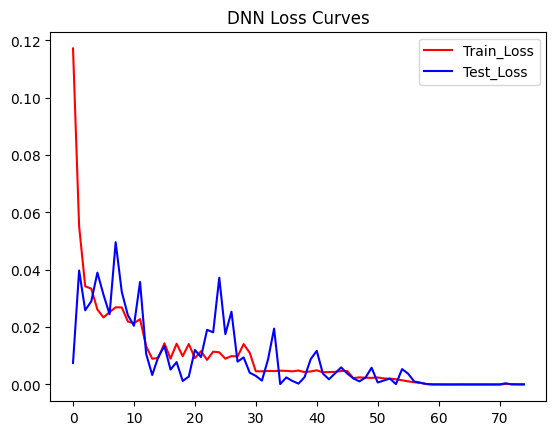

In [ ]:

ep = []
result1 = []
result2 = []
best_loss = torch.inf

import numpy as np
print("Before training | Test Loss:", test(test_load, model, loss_fn))
for epoch in trange (num_epochs, desc="Processing"):

    train_loss = train(train_load, model, optimizer, loss_fn)
    test_loss = test( test_load,model, loss_fn)
    ep.append(epoch)
    result1.append(np.array(torch.tensor(train_loss).numpy()))
    result2.append(np.array(torch.tensor(test_loss).numpy()))


    print(f"Epoch {epoch} | Train Loss: {train_loss} | Test Loss: {test_loss}")

    if epoch < swa_start:
        scheduler_llr.step(test_loss)
    else:
        swa_model.update_parameters(model)
        swa_scheduler.step()
        scheduler_csa.step()

    #early stopping and saving model
    if test_loss < best_loss:
        best_loss = test_loss
        counter = 0
        torch.save(model.state_dict(), 'DNN.pt')
    else:
        counter += 1

    if counter >= early_stop_patience:
        print("Early stopping triggered")
        break

print(f"Best for test Loss: {best_loss}")
#plotting loss curves
plt.plot(ep, result1, color = "red", label = "Train_Loss")
plt.plot(ep, result2, color = "blue", label="Test_Loss")
plt.legend()
plt.title("DNN Loss Curves")
plt.show()

In [ ]:
model = DNN(in_shape=4, hidden_units=256, out_shape=1, num_layers=7).to(device)

# Check initial outputs:
sample = next(iter(train_load))
inputs = sample[:, [0,1,2,4]].to(device)
with torch.inference_mode():
    out = model(inputs)
print(out)
# Should now be around -5, not 0.01

tensor([[2.7776e-04],
        [2.4731e-05],
        [1.9408e-04],
        ...,
        [4.7217e-04],
        [2.7058e-05],
        [2.0052e-04]], device='cuda:0')


Best for test Loss: -1.1372934075974209e-08


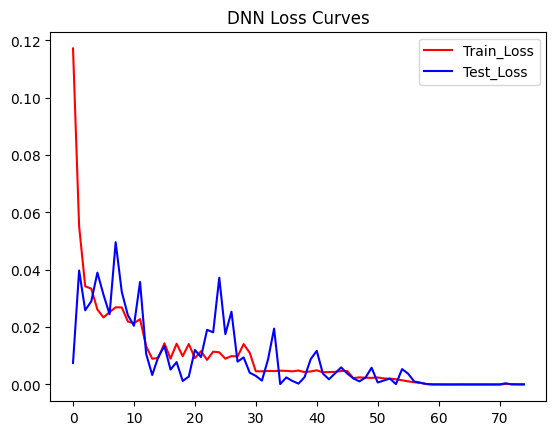

In [ ]:
print(f"Best for test Loss: {best_loss}")
#plotting loss curves
plt.plot(ep, result1, color = "red", label = "Train_Loss")
plt.plot(ep, result2, color = "blue", label="Test_Loss")
plt.legend()
plt.title("DNN Loss Curves")
plt.show()

In [ ]:

model_test = DNN(in_shape = 4, hidden_units = 256, out_shape = 1, num_layers = 7).to(device)
model_test.load_state_dict(torch.load('DNN.pt', weights_only=True))
model_test.to(device)

DNN(
  (convs): ModuleList(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): ReLU()
    (10): Linear(in_features=256, out_features=256, bias=True)
    (11): ReLU()
    (12): Linear(in_features=256, out_features=1, bias=True)
  )
)

In [ ]:
data_test = np.loadtxt("Paper/dataset_172.0.txt")
zeta1, zeta2, zeta3 = data_test[:,0], data_test[:,1], data_test[:,2]
E_tilde = data_test[:,3]
mt = torch.tensor([172.0]*len(data_test))

#compute perimeter and asymmetry
zp = zeta1 + zeta2 + zeta3
delta_a = zeta3 - zeta1

#equilateral filter
mask = delta_a <= 0.02

#Pythia histogram
bins = np.linspace(0.04, 0.10, 30)
centers = 0.5 * (bins[:-1] + bins[1:])

eeec_mc = np.zeros(len(centers))

for i in range(len(centers)):
    mask_bin = ((zp >= bins[i]) &(zp < bins[i+1]) & mask)
    eeec_mc[i] = E_tilde[mask_bin].sum()

eeec_mc /= np.trapezoid(eeec_mc, centers)

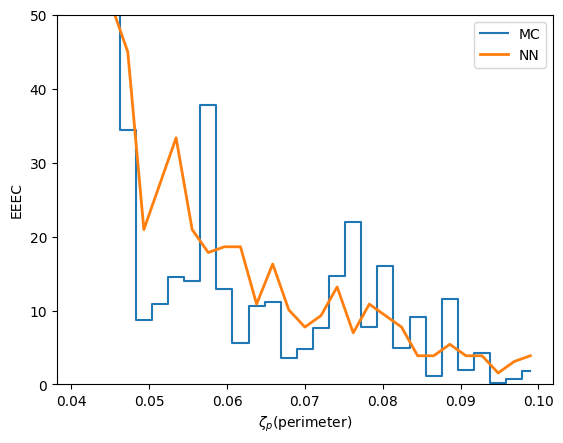

In [ ]:

#NN
params = torch.load('preprocessing_params.pt')
raw_mins = params['raw_mins']
raw_maxs = params['raw_maxs']
post_mins = params['post_mins']
post_maxs = params['post_maxs']

def preprocess_zeta(z, col):
    z_log  = np.log10(z / raw_mins[col]) / np.log10(raw_maxs[col] / raw_mins[col])
    z_norm = (z_log - post_mins[col]) / (post_maxs[col] - post_mins[col])
    return z_norm
def preprocess_mt(mt):
    mt_norm = (mt - post_mins[4]) / (post_maxs[4] - post_mins[4])
    return mt_norm


X = np.stack([zeta1, zeta2, zeta3, mt], axis=1)

X[:,0] = preprocess_zeta(X[:,0], col=0)
X[:,1] = preprocess_zeta(X[:,1], col=1)
X[:,2] = preprocess_zeta(X[:,2], col=2)
X[:,3] = preprocess_mt(X[:,3])

X = torch.tensor(X, dtype=torch.float32).to(device)

with torch.no_grad():
    eeec_nn = torch.exp(model_test(X))

eeec_nn_binned = np.zeros(len(centers))

for i in range(len(centers)):

    mask_bin = ((zp >= bins[i]) &(zp < bins[i+1]) & mask)
    eeec_nn_binned[i] = eeec_nn[mask_bin].sum()

eeec_nn_binned /= np.trapezoid(eeec_nn_binned, centers)
plt.step(
    centers,
    eeec_mc,
    where='mid',
    label='MC'
)

plt.plot(
    centers,
    eeec_nn_binned,
    linewidth=2,
    label='NN'
)

plt.xlabel(r'$\zeta_{p}$(perimeter)')
plt.ylabel('EEEC')
plt.ylim(0,50)
plt.legend()
plt.show()

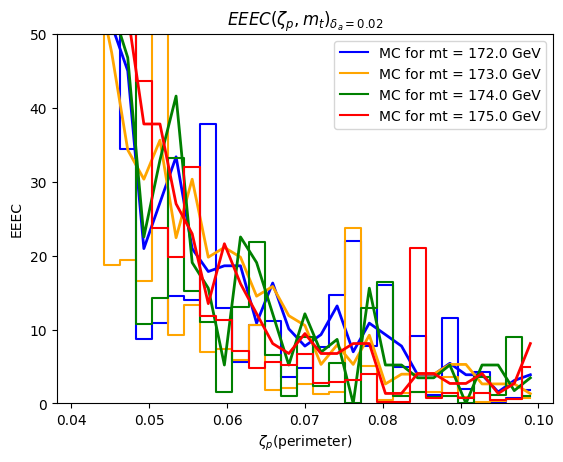

In [ ]:
colour = ["blue", "orange", "green", "red"]
t = 0
for i in range(172,176,1):

    i = round(i*1.0,1)
    string_i = "Paper/dataset_"+ str(i) + ".txt"
    data_test = np.loadtxt(string_i)
    zeta1, zeta2, zeta3 = data_test[:,0], data_test[:,1], data_test[:,2]
    E_tilde = data_test[:,3]
    mt = torch.tensor([172.0]*len(data_test))

    #compute perimeter and asymmetry
    zp = zeta1 + zeta2 + zeta3
    delta_a = zeta3 - zeta1

    #equilateral filter
    mask = delta_a <= 0.02

    #Pythia histogram
    bins = np.linspace(0.04, 0.10, 30)
    centers = 0.5 * (bins[:-1] + bins[1:])

    eeec_mc = np.zeros(len(centers))

    for q in range(len(centers)):
        mask_bin = ((zp >= bins[q]) &(zp < bins[q+1]) & mask)
        eeec_mc[q] = E_tilde[mask_bin].sum()

    eeec_mc /= np.trapezoid(eeec_mc, centers)


    X = np.stack([zeta1, zeta2, zeta3, mt], axis=1)

    X[:,0] = preprocess_zeta(X[:,0], col=0)
    X[:,1] = preprocess_zeta(X[:,1], col=1)
    X[:,2] = preprocess_zeta(X[:,2], col=2)
    X[:,3] = preprocess_mt(X[:,3])

    X = torch.tensor(X, dtype=torch.float32).to(device)

    with torch.no_grad():
        eeec_nn = torch.exp(model_test(X))

    eeec_nn_binned = np.zeros(len(centers))

    for g in range(len(centers)):

        mask_bin = ((zp >= bins[g]) &(zp < bins[g+1]) & mask)
        eeec_nn_binned[g] = eeec_nn[mask_bin].sum()

    eeec_nn_binned /= np.trapezoid(eeec_nn_binned, centers)

    plt.step(
    centers,
    eeec_mc,
    where='mid',
    label=f'MC for mt = {i} GeV',
    color = colour[t]
)

    plt.plot(
    centers,
    eeec_nn_binned,
    linewidth=2,
    color = colour[t]
)
    t += 1

plt.ylim(0,50)
plt.title(r'$EEEC(\zeta_p, m_t)_{\delta_a=0.02}$')
plt.ylabel('EEEC')
plt.xlabel(r'$\zeta_{p}$(perimeter)')
plt.legend()
plt.show()

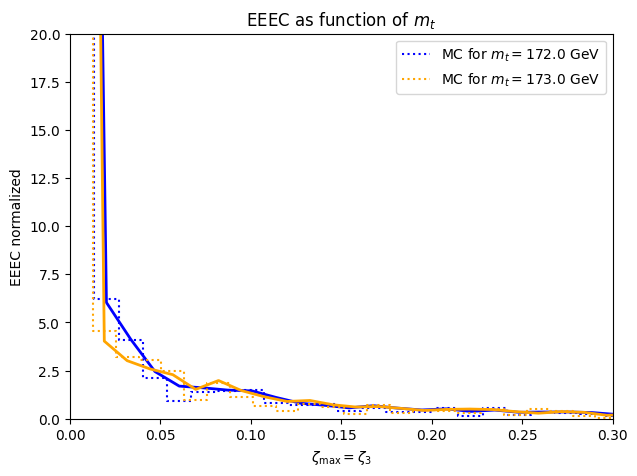

In [ ]:
#zeta 3
colour = ["blue", "orange"]
t = 0
plt.figure(figsize=(7,5))

for i in range(172,174,1):
  i = round(i*1.0,1)
  data_test = np.loadtxt("Paper/dataset_"+str(i)+".txt")
  zeta1, zeta2, zeta3 = data_test[:,0], data_test[:,1], data_test[:,2]
  E_tilde = data_test[:,3]
  mt = torch.tensor([172.0]*len(data_test))

  bins = np.linspace(zeta3.min(), zeta3.max(),50)
  centers = 0.5 * (bins[:-1] + bins[1:])

  eeec_mc = np.zeros(len(centers))
  for s in range(len(centers)):
    mask_bin = (zeta3>=bins[s]) & (zeta3<bins[s+1])
    eeec_mc[s] = E_tilde[mask_bin].sum()

  eeec_mc /= np.trapezoid(eeec_mc,centers)

  X = np.stack([zeta1,zeta2,zeta3,mt],axis = 1)

  X[:,0] = preprocess_zeta(X[:,0],col=0)
  X[:,1] = preprocess_zeta(X[:,1],col=1)
  X[:,2] = preprocess_zeta(X[:,2],col=2)
  X[:,3] = preprocess_mt(X[:,3])

  X = torch.tensor(X, dtype=torch.float32).to(device)

  with torch.no_grad():
      eeec_nn = torch.exp(model_test(X))

  eeec_nn_binned = np.zeros(len(centers))

  for g in range(len(centers)):
    mask_bin = (zeta3 >= bins[g]) & (zeta3 < bins[g+1])
    eeec_nn_binned[g] = eeec_nn[mask_bin].sum()

  eeec_nn_binned /= np.trapezoid(eeec_nn_binned, centers)

  plt.step(
      centers,
      eeec_mc,
      where='mid',
      label=f'MC for $m_t = {i}$ GeV',
      color = colour[t],
      linestyle=':'
  )

  plt.plot(
      centers,
      eeec_nn_binned,
      linewidth=2,
      color = colour[t]
  )
  t += 1

plt.xlabel(r'$\zeta_{\max}=\zeta_3$')
plt.ylabel('EEEC normalized')
plt.legend()
plt.title(r'EEEC as function of $m_t$')
plt.xlim(0.0,0.3)
plt.ylim(0,20)
plt.show()

In [ ]:
print("eeec_nn_binned:", eeec_nn_binned)
print("trapezoid:", np.trapezoid(eeec_nn_binned, centers))
print("any nonzero:", np.any(eeec_nn_binned > 0))

eeec_nn_binned: [1.04330247e+02 4.03098783e+00 3.01621156e+00 2.58678483e+00
 2.28771979e+00 1.52344245e+00 1.98354252e+00 1.46209578e+00
 1.14258184e+00 8.97195135e-01 9.48317365e-01 7.25935665e-01
 6.08354536e-01 6.33915651e-01 5.36783414e-01 4.29426731e-01
 4.85661184e-01 5.03553965e-01 4.75436738e-01 3.68080055e-01
 2.86284487e-01 3.68080055e-01 3.32294494e-01 1.78927805e-01
 2.30050035e-01 2.53055038e-01 9.45761253e-02 1.43142244e-01
 1.15025017e-01 5.36783414e-02 6.13466759e-02 4.60100069e-02
 4.08977839e-02 2.55611150e-02 1.78927805e-02 2.55611150e-02
 5.11222299e-03 5.11222299e-03 7.66833449e-03 1.27805575e-02
 2.55611150e-03 1.02244460e-02 2.55611150e-03 5.11222299e-03
 1.02244460e-02 2.55611150e-03 5.11222299e-03 0.00000000e+00
 0.00000000e+00]
trapezoid: 1.0
any nonzero: True


In [ ]:
for mt in [170, 178]:

    print(f"\nmt = {mt}")

    for z1 in [0.01, 0.02, 0.03]:

        z2 = 1.0 * z1
        z3 = 1.0 * z1

        sides = np.sort([z1,z2,z3])

        s1 = preprocess_zeta(sides[0], col=0)
        s2 = preprocess_zeta(sides[1], col=1)
        s3 = preprocess_zeta(sides[2], col=2)
        s4 = preprocess_mt(mt)

        inputs = torch.tensor([[s1,s2,s3,s4]],
                              dtype=torch.float32).to(device)

        with torch.no_grad():
            out = model_test(inputs)

        print(f"z1={z1:.3f} -> {out.item():.8f}")


mt = 170
z1=0.010 -> 0.00000003
z1=0.020 -> 0.00000003
z1=0.030 -> 0.00000003

mt = 178
z1=0.010 -> 0.00000003
z1=0.020 -> 0.00000003
z1=0.030 -> 0.00000003


In [ ]:
print(X.min(), X.max())

tensor(-0.2126, device='cuda:0') tensor(1.0653, device='cuda:0')


In [ ]:
print("Any NaNs?", np.isnan(eeec_nn.cpu()).any())
print("Integral =", np.trapezoid(eeec_nn_binned, centers))

Any NaNs? tensor(0, dtype=torch.uint8)
Integral = 1.0


/tmp/ipykernel_6377/589557261.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print("Any NaNs?", np.isnan(eeec_nn.cpu()).any())


In [ ]:
print("Input ranges:")
print(X[:,0].min(), X[:,0].max())
print(X[:,1].min(), X[:,1].max())
print(X[:,2].min(), X[:,2].max())

Input ranges:
tensor(-0.2126, device='cuda:0') tensor(1.0653, device='cuda:0')
tensor(-0.1599, device='cuda:0') tensor(1.0498, device='cuda:0')
tensor(-0.2073, device='cuda:0') tensor(1.0506, device='cuda:0')


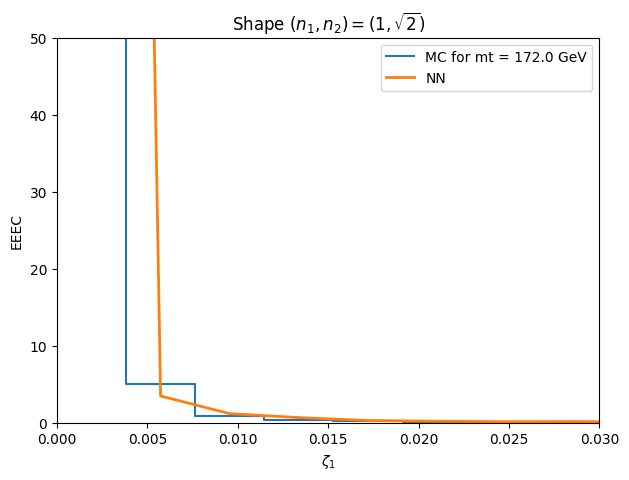

In [ ]:
n1 = 1.0
n2 = np.sqrt(2)
delta_a = 0.01
shape_mask = ((np.abs(zeta2 - n1*zeta1) < delta_a) & (np.abs(zeta3 - n2*zeta1) < delta_a))

# selected z1 values
z1_sel = zeta1[shape_mask]
# selected EEEC weights
E_sel = E_tilde[shape_mask]

bins = np.linspace(z1_sel.min(), z1_sel.max(), 50)
centers = 0.5*(bins[:-1] + bins[1:])
eeec_mc = np.zeros(len(centers))

for i in range(len(centers)):
    mask_bin = ((z1_sel >= bins[i]) &(z1_sel < bins[i+1]))
    eeec_mc[i] = E_sel[mask_bin].sum()

eeec_mc /= np.trapezoid(eeec_mc, centers)

X_sel = np.stack([zeta1[shape_mask],zeta2[shape_mask],zeta3[shape_mask],mt[shape_mask]], axis=1)

X_sel[:,0] = preprocess_zeta(X_sel[:,0], col=0)
X_sel[:,1] = preprocess_zeta(X_sel[:,1], col=1)
X_sel[:,2] = preprocess_zeta(X_sel[:,2], col=2)
X_sel[:,3] = preprocess_mt(X_sel[:,3])

X_sel = torch.tensor(X_sel,dtype=torch.float32).to(device)

with torch.no_grad():
    eeec_nn = torch.exp(model_test(X_sel)).cpu().numpy().flatten()

eeec_nn_binned = np.zeros(len(centers))

for i in range(len(centers)):

    mask_bin = ((z1_sel >= bins[i]) &(z1_sel < bins[i+1]))
    eeec_nn_binned[i] = eeec_nn[mask_bin].sum()

eeec_nn_binned /= np.trapezoid(eeec_nn_binned,centers)

plt.figure(figsize=(7,5))

plt.step(
    centers,
    eeec_mc,
    where='mid',
    label=f'MC for mt = {mt[0]} GeV'
)

plt.plot(
    centers,
    eeec_nn_binned,
    linewidth=2,
    label='NN'
)

plt.xlabel(r'$\zeta_1$')
plt.ylabel('EEEC')
plt.title(r'Shape $(n_1,n_2)=(1,\sqrt{2})$')
plt.legend()
plt.xlim(0,0.03)
plt.ylim(0,50)
plt.show()

#Triangle shape ζ1 × (1, n1, n2) means:
  side 1 = ζ1        (free parameter, scanned)

  side 2 = n1 × ζ1   (n1 times larger than side 1)

  side 3 = n2 × ζ1   (n2 times larger than side 1)

#Examples:
  (n1,n2) = (1,1)    → equilateral triangle

  (n1,n2) = (1,√2)   → right isosceles triangle
  
  (n1,n2) = (1,2)    → one short, two longer sides

In [ ]:
def EEEC_curve(n1, n2, mt, model, a=0.01):

  #zeta1 -> (0.02/3, 0.1/3, 100)
  l1 = 0.02/3
  l2 = 0.1/3
  l = np.linspace(l1,l2,100)
  eeec_vals = []

  for z1 in l:
    samples =[]
    for _ in range(200):

      z2 = np.random.uniform(n1*z1, n1*z1 + a)
      z3 = np.random.uniform(n2*z1, n2*z1 + a)
      #sorting z1, z2, z3
      sides = np.sort([z1, z2, z3])

      #preprocess out inputs
      s1 = preprocess_zeta(sides[0], col=0)
      s2 = preprocess_zeta(sides[1], col=1)
      s3 = preprocess_zeta(sides[2], col=2)
      s4 = preprocess_mt(mt)

      inputs = torch.tensor([[s1,s2,s3,s4]], dtype=torch.float32).to(device)
      with torch.no_grad():
          eeec_nn = torch.exp(model(inputs)).item() #(1,1)
          samples.append(eeec_nn)
    eeec_vals.append(np.mean(samples) if samples else 0)

  eeec_vals=np.array(eeec_vals)
  eeec_vals /= eeec_vals.sum() #Normalization condition

  return l,eeec_vals

In [ ]:
#Adding Gaussian noise at 5% level if perfect
def Gaussian_lvl(eeec_vals, noise_level = 0.05):
  noise = np.random.normal(0, noise_level, len(eeec_vals))
  return eeec_vals * (1 + noise)

In [ ]:
#dataset
dataset = []
num_samples = 15000

for i in trange(num_samples, desc="Descending"):
  # Fix:
  n1_raw = np.random.exponential(1.0) + 1.0  # +1 to ensure > 1
  n2_raw = np.random.exponential(1.0) + 1.0
  n1 = min(n1_raw, n2_raw)   # n1 ≤ n2
  n2 = max(n1_raw, n2_raw)
  #n1>n2
  n1_log = np.log(n1)
  n2_log = np.log(n2)
  mt_true = np.random.uniform(170.0,179.9)

  _, eeec = EEEC_curve(n1, n2, mt_true, model_test)
  shape = Gaussian_lvl(eeec)
  mt_true = preprocess_mt(mt_true)

  #data1 -> joint sample, label = 1
  dataset.append([shape, mt_true, n1_log, n2_log,1])
  #data2 -> marginal sample, label = 0
  mt_fake = np.random.uniform(170.0, 179.9)
  mt_fake = preprocess_mt(mt_fake)
  dataset.append([shape, mt_fake, n1_log, n2_log,0])

dataset_fixed = []

for shape, mt, n1, n2, label in dataset:
    sample = np.concatenate([shape,[mt, n1, n2, label]])
    dataset_fixed.append(sample)

dataset = torch.tensor(np.array(dataset_fixed), dtype=torch.float32)

#Creating training and testing datasets
batch_size = 2000
test_size = 0.1
num_samples = len(dataset)

test_no = int(test_size * num_samples)
train_no = len(dataset) - test_no

np.random.seed(42)
indices = np.arange(len(dataset))
np.random.shuffle(indices)

train_index, test_index = indices[:train_no], indices[train_no:train_no+test_no]

# define samplers for obtaining training and testing batches
train_sampler = SubsetRandomSampler(train_index)
test_sampler = SubsetRandomSampler(test_index)

train_load = DataLoader(dataset, batch_size = batch_size, sampler = train_sampler)
test_load = DataLoader(dataset, batch_size = batch_size, sampler = test_sampler)




Descending: 100%|██████████| 15000/15000 [12:36<00:00, 19.83it/s]


In [ ]:
len(sample),len(shape),shape[:100]

(104,
 100,
 array([0.01033925, 0.01100352, 0.0099786 , 0.01001734, 0.00972837,
        0.0106617 , 0.00998435, 0.01007417, 0.01045167, 0.00968729,
        0.00932821, 0.01044567, 0.00962372, 0.01029233, 0.00983421,
        0.01061069, 0.00986659, 0.01000966, 0.00956384, 0.00974334,
        0.01037557, 0.01002732, 0.00929775, 0.01060826, 0.0104635 ,
        0.00988412, 0.00977615, 0.01055679, 0.00999128, 0.01001386,
        0.01020713, 0.00979068, 0.01013175, 0.0103294 , 0.01001711,
        0.00894265, 0.01031042, 0.00951408, 0.01007037, 0.01001452,
        0.00994888, 0.00974326, 0.00972011, 0.01021531, 0.00988939,
        0.01020244, 0.00998183, 0.01015403, 0.00933372, 0.00994999,
        0.00958712, 0.0098636 , 0.0096849 , 0.01081936, 0.00939149,
        0.00932205, 0.00991834, 0.0096302 , 0.01012458, 0.01014521,
        0.01064384, 0.01034064, 0.00959896, 0.01032627, 0.00981154,
        0.01001018, 0.00969534, 0.00912508, 0.00998291, 0.00940466,
        0.01018414, 0.01016526, 0.00

In [ ]:
#from above function I already have my ζshape and  ϵi=0 noise
#let us do the model first

#Model
class SummaryNetwork(nn.Module):
    def __init__(self,in_shape: int,hidden_units: int, out_shape: int, num_layers: int, dp_list):
        #in_shape = 100; hidden_units = 128, out_shape = 1, num_layers = 5
        super().__init__()

        #Layers of calling
        self.convs = nn.ModuleList()
        self.convs.append(nn.Linear(in_shape, hidden_units))
        self.convs.append(nn.ELU())
        self.convs.append(nn.Dropout(dp_list[0]))

        for i in range(num_layers-2):
            self.convs.append(nn.Linear(hidden_units, hidden_units))
            self.convs.append(nn.ELU())
            self.convs.append(nn.Dropout(dp_list[i+1]))
        self.convs.append(nn.Linear(hidden_units, out_shape))

    def forward(self, x: torch.Tensor):
        for conv in self.convs:
            x = conv(x) #(batch, 1)

        return x #s_phi

class ClassifierNetwork(nn.Module):
    def __init__(self,in_shape: int,hidden_units: int, out_shape: int, num_layers: int):
        #in_shape = 4; hidden_units = 128, out_shape = 1, num_layers = 5
        super().__init__()

        #Layers of calling
        self.convs = nn.ModuleList()
        self.convs.append(nn.Linear(in_shape, hidden_units))
        self.convs.append(nn.ELU())

        for i in range(num_layers-2):
            self.convs.append(nn.Linear(hidden_units, hidden_units))
            self.convs.append(nn.ELU())
        self.convs.append(nn.Linear(hidden_units, out_shape))

    def forward(self, x: torch.Tensor):
        for conv in self.convs:
            x = conv(x) #(batch, 1)

        return x #f_phi

class NRE(nn.Module):

    def __init__(
        self,summary_in,summary_hidden,summary_out,summary_layers,dp_list,
        classifier_in,classifier_hidden,classifier_out,classifier_layers
    ):

        super().__init__()

        self.summary = SummaryNetwork(
            in_shape=summary_in,
            hidden_units=summary_hidden,
            out_shape=summary_out,
            num_layers=summary_layers,
            dp_list=dp_list
        )

        self.classifier = ClassifierNetwork(
            in_shape=classifier_in,
            hidden_units=classifier_hidden,
            out_shape=classifier_out,
            num_layers=classifier_layers
        )

    def forward(self, zeta_shape, mt, n1, n2):

        s_phi = self.summary(zeta_shape)
        #print(s_phi.shape, mt.shape, n1.shape, n2.shape)
        inp = torch.cat([s_phi, mt, n1, n2], dim=1)
        return self.classifier(inp)

In [ ]:
next(iter(train_load)).shape

torch.Size([2000, 104])

In [ ]:
#training model
#as far as NRE is concerned I am pretty sure he is talking about the EEEC which is normalised
#if so, then we have (batch, in_shape=100)

def train(train_loader, model, optimizer, loss_fn):
    model.train()
    train_loss = 0
    i = 0

    for data in tqdm(train_loader, desc="Training batches"):

        data= data.to(device)
        labels = data[:,-1].unsqueeze(1)
        #model = NRE
        X = data[:, :-1]

        y_pred = model(X[:,:100], X[:,100].unsqueeze(1),X[:,101].unsqueeze(1), X[:,102].unsqueeze(1))
        loss = loss_fn(y_pred, labels)

        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        i+= 1

    train_loss /= len(train_loader)
    return train_loss


def test(test_loader, model, loss_fn):
    model.eval()
    test_loss = 0

    with torch.inference_mode():
         for data in tqdm(test_loader, desc="Training batches"):
            data = data.to(device)
            labels = data[:,-1].unsqueeze(1)
            #model = NRE
            X = data[:, :-1]
            test_pred = model(X[:,:100], X[:,100].unsqueeze(1),X[:,101].unsqueeze(1), X[:,102].unsqueeze(1))
            loss = loss_fn(test_pred, labels)

            test_loss += loss.item()

    test_loss /= len(test_loader)

    return test_loss

In [ ]:
#self,summary_in,summary_hidden,summary_out,summary_layers,dp_list,
#        classifier_in,classifier_hidden,classifier_out,classifier_layers
#loss
loss_fn = nn.BCEWithLogitsLoss()
#model
model_NRE = NRE(100,128,1,5,[0,0.01,0.02,0.04,0.08],4,128,1,5).to(device)
#optimizer
optimizer = torch.optim.Adam(model_NRE.parameters(),lr = 1e-3)

#scheduler
scheduler_csa = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20,
    eta_min=1e-6
)

#added for reproducing the paper
from torch.optim.swa_utils import AveragedModel
swa_model = AveragedModel(model_NRE)
swa_scheduler = torch.optim.swa_utils.SWALR(
    optimizer,
    swa_lr=8e-7
)

Training batches: 100%|██████████| 14/14 [00:00<00:00, 101.39it/s]

Processing:   0%|          | 1/600 [00:00<01:36,  6.19it/s]

Epoch 0 | Train Loss: 0.6936354679720742 | Test Loss: 0.6930859684944153



Training batches: 100%|██████████| 14/14 [00:00<00:00, 124.77it/s]

Processing:   0%|          | 2/600 [00:00<01:25,  6.97it/s]

Epoch 1 | Train Loss: 0.6932935757296426 | Test Loss: 0.6931332647800446



Training batches: 100%|██████████| 14/14 [00:00<00:00, 115.52it/s]

Processing:   0%|          | 3/600 [00:00<01:24,  7.07it/s]

...

Epoch 218 | Train Loss: 0.6931483660425458 | Test Loss: 0.6930506527423859



Training batches: 100%|██████████| 14/14 [00:00<00:00, 52.63it/s]

Processing:  37%|███▋      | 220/600 [00:34<01:14,  5.11it/s]

Epoch 219 | Train Loss: 0.6931173418249402 | Test Loss: 0.6931313574314117



Training batches: 100%|██████████| 14/14 [00:00<00:00, 103.98it/s]

Processing:  37%|███▋      | 220/600 [00:34<01:00,  6.29it/s]


Epoch 220 | Train Loss: 0.6931627179895129 | Test Loss: 0.6931300759315491
Early stopping at epoch 220
Best for test Loss: 0.6930077075958252


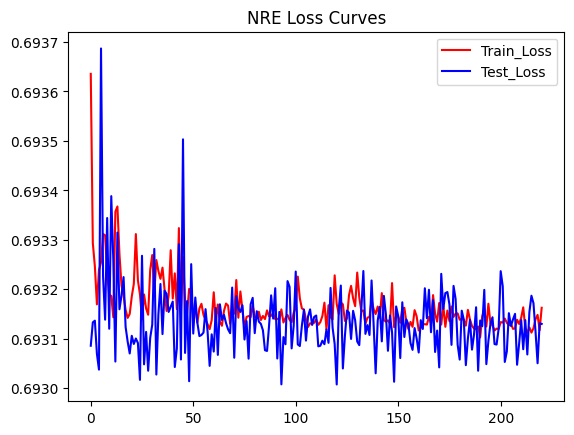

In [ ]:
swa_start = 480
counter = 0
early_stop_patience = 100

ep = []
result1 = []
result2 = []
best_loss = torch.inf
swa_reached = False

import numpy as np
for epoch in trange (600, desc="Processing"):

    train_loss = train(train_load, model_NRE, optimizer, loss_fn)
    test_loss = test( test_load,model_NRE, loss_fn)
    ep.append(epoch)
    result1.append(np.array(torch.tensor(train_loss).numpy()))
    result2.append(np.array(torch.tensor(test_loss).numpy()))


    print(f"Epoch {epoch} | Train Loss: {train_loss} | Test Loss: {test_loss}")

    if epoch < swa_start:
        # Phase 1: normal training, no SWA
        # Early stopping only in this phase:
        if test_loss < best_loss:
            best_loss = test_loss
            counter = 0
            torch.save(model_NRE.state_dict(), 'NRE.pt')
        else:
            counter += 1

        if counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break

    else:
        # Phase 2: SWA with cosine annealing
        # Paper uses cosine annealing OVER 20 epochs within SWA:
        swa_model.update_parameters(model_NRE)
        swa_reached = True
        # Cosine annealing lr over 20 epoch cycles:
        scheduler_csa.step()   # ← this IS the cosine annealing for SWA phase

# After training — one save location:
if swa_reached:
    torch.optim.swa_utils.update_bn(train_load, swa_model)
    torch.save(swa_model.state_dict(), 'NRE.pt')  # overwrite with SWA

print(f"Best for test Loss: {best_loss}")
#plotting loss curves
plt.plot(ep, result1, color = "red", label = "Train_Loss")
plt.plot(ep, result2, color = "blue", label="Test_Loss")
plt.legend()
plt.title("NRE Loss Curves")
plt.show()

In [ ]:
sample = next(iter(train_load)).to(device)
with torch.no_grad():
    out1 = model_NRE(sample[:1,:100], sample[:1,100:101],
                     sample[:1,101:102], sample[:1,102:103])
    out2 = model_NRE(sample[1:2,:100], sample[1:2,100:101],
                     sample[1:2,101:102], sample[1:2,102:103])
print(f"out1={out1.item():.4f}  out2={out2.item():.4f}")

out1=-0.0027  out2=-0.0270


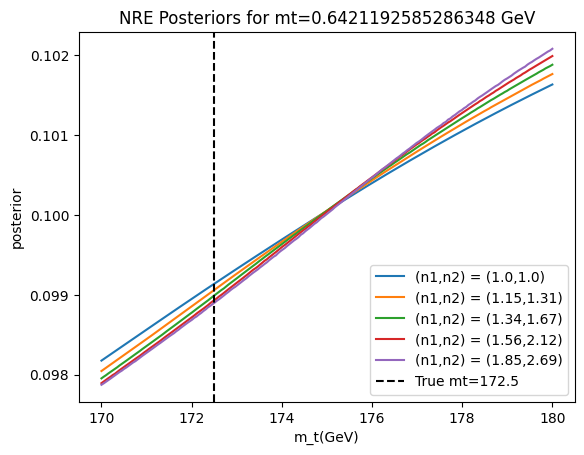

In [ ]:
model_test_NRE = NRE(100,128,1,5,[0,0.01,0.02,0.04,0.08],4,128,1,5).to(device)
model_test_NRE.load_state_dict(torch.load('NRE.pt', weights_only=True))
model_test_NRE.to(device)


#since we trained NRE, now we pass on the dataset to get posteriors
mt_p = 172.5
n1_vals = [1.00,1.15,1.34,1.56,1.85]
n2_vals = [1.00,1.31,1.67,2.12,2.69]

#N = int((180-170)/0.25 + 1)
mt_grid = np.linspace(170,180,200)


for i in range(5):

    n1 = n1_vals[i]
    n2 = n2_vals[i]
    #getting EEEC shape from NRE and adding noise
    _,shape = EEEC_curve(n1,n2,mt_p,model_test)
    shape_noisy = torch.tensor(Gaussian_lvl(shape),dtype=torch.float32).to(device)

    posteriors = []
    shape_t = shape_noisy.unsqueeze(0)

    for m in mt_grid:
        # Preprocessing:
        mt_norm = (m - mt_grid[0]) / (mt_grid[-1] - mt_grid[0])
        n1_log  = np.log(n1)
        n2_log  = np.log(n2)

        # Convert to tensors [1, 1]:
        mt_t = torch.tensor([[mt_norm]], dtype=torch.float32).to(device)
        n1_t = torch.tensor([[n1_log]],  dtype=torch.float32).to(device)
        n2_t = torch.tensor([[n2_log]],  dtype=torch.float32).to(device)

        with torch.no_grad():
            f = model_test_NRE(shape_t, mt_t, n1_t, n2_t)

        posteriors.append(torch.exp(f).item())

    #normalize
    posteriors = np.array(posteriors)
    norm = np.trapezoid(posteriors, mt_grid)
    if norm > 0:
        posteriors /= norm

    plt.plot(mt_grid, posteriors, label=f'(n1,n2) = ({n1},{n2})')

plt.axvline(mt_p, color='k', linestyle='--', label=f"True mt={mt_p}")
plt.xlabel("m_t(GeV)")
plt.ylabel("posterior")
plt.title(f"NRE Posteriors for mt={mt_p} GeV")
plt.legend()
plt.show()
#Fig 7a generated

In [ ]:
# Print first few samples:
for i in range(4):
    label = dataset[i, -1].item()
    mt    = dataset[i, 100].item()
    print(f"Sample {i}: label={label}  mt={mt:.4f}")


Sample 0: label=1.0  mt=0.0504
Sample 1: label=0.0  mt=0.6126
Sample 2: label=1.0  mt=0.8935
Sample 3: label=0.0  mt=0.4136


Max difference between mt=172 and mt=178 shapes: 0.000000
Mean difference: 0.000000


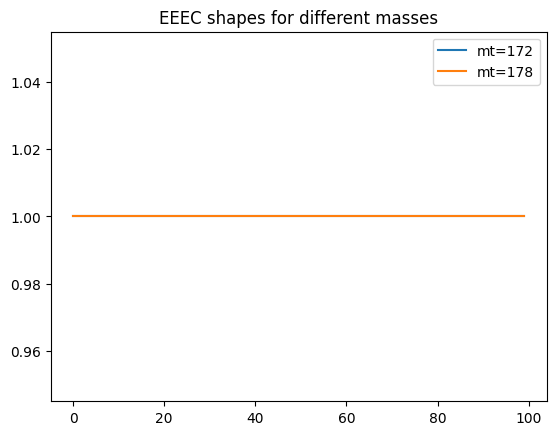

In [ ]:
# Are shapes actually different for different masses?
_, shape_172 = EEEC_curve(1.0, 1.0, 172.0, model_test)
_, shape_178 = EEEC_curve(1.0, 1.0, 178.0, model_test)

print(f"Max difference between mt=172 and mt=178 shapes: {np.max(np.abs(shape_172 - shape_178)):.6f}")
print(f"Mean difference: {np.mean(np.abs(shape_172 - shape_178)):.6f}")

plt.plot(shape_172, label='mt=172')
plt.plot(shape_178, label='mt=178')
plt.legend()
plt.title("EEEC shapes for different masses")
plt.show()

In [ ]:
def EEEC_curve_delta(n1, n2, mt, model, a=0.01):

  #zeta1 -> (0.02/3, 0.1/3, 100)
  l1 = 0.02/3
  l2 = 0.1/3
  l = np.linspace(l1,l2,100)
  eeec_vals = []

  for z1 in l:
    samples =[]
    for _ in range(200):

      z2 = np.random.uniform(n1*z1, n1*z1 + a)
      z3 = np.random.uniform(n2*z1, n2*z1 + a)
      #sorting z1, z2, z3
      sides = np.sort([z1, z2, z3])

      #preprocess out inputs
      s1 = preprocess_zeta(sides[0], col=0)
      s2 = preprocess_zeta(sides[1], col=1)
      s3 = preprocess_zeta(sides[2], col=2)
      s4 = preprocess_mt(mt)

      inputs = torch.tensor([[s1,s2,s3,s4]], dtype=torch.float32).to(device)
      with torch.no_grad():
          eeec_nn = torch.exp(model(inputs)).item() #(1,1)
          samples.append(eeec_nn)
    eeec_vals.append(np.mean(samples) if samples else 0)

  eeec_vals=np.array(eeec_vals)
  eeec_vals /= eeec_vals.sum() #Normalization condition

  return l,eeec_vals

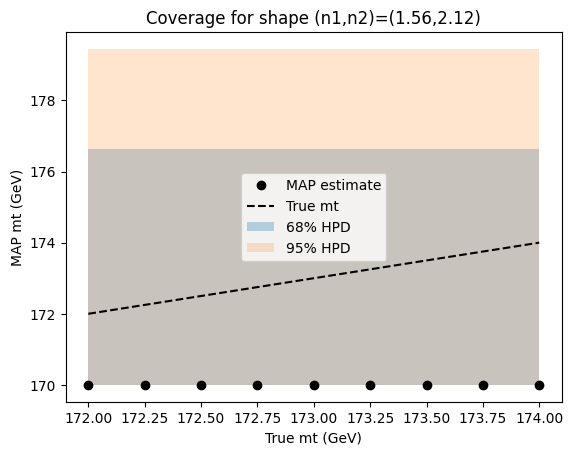

In [ ]:
# Scan over grid of shapes:
n1, n2 = n1_vals[3], n2_vals[3]

mt_true_vals = np.arange(172.0, 174.25, 0.25)

#calculating posterior for various mt
maps = []
hpd68_lo, hpd68_hi = [], []
hpd95_lo, hpd95_hi = [], []

for mt_true in mt_true_vals:                    # outer loop
    _, shape = EEEC_curve_delta(n1, n2, mt_true, model_test)
    shape_noisy = Gaussian_lvl(shape)

    posteriors = []
    shape_t = torch.tensor(shape_noisy, dtype=torch.float32).unsqueeze(0).to(device)

    for m in mt_grid:                           #inner loop
        mt_norm = (m - mt_grid[0]) / (mt_grid[-1] - mt_grid[0])
        mt_t = torch.tensor([[mt_norm]], dtype=torch.float32).to(device)
        n1_t = torch.tensor([[np.log(n1)]], dtype=torch.float32).to(device)
        n2_t = torch.tensor([[np.log(n2)]], dtype=torch.float32).to(device)

        with torch.no_grad():
            f = model_test_NRE(shape_t, mt_t, n1_t, n2_t)
        posteriors.append(torch.exp(f).item())

    #normalize
    posteriors = np.array(posteriors)
    norm = np.trapezoid(posteriors, mt_grid)
    if norm > 0:
      posteriors /= norm

    #finds the mass to which posterior is highest for each true mass
    maps.append(mt_grid[np.argmax(posteriors)])
    #we plot this mass vs the true mass to find out if the relation is afterall collinear

    #next we find the HPD interval

    #first lets sort the indices accordingly in descending way
    sorted_idx = np.argsort(posteriors)[::-1]

    #accumulate probability

    ci = [0.68, 0.95]
    dx = mt_grid[1] - mt_grid[0]
    CI_dict = {}

    for CI in ci:
      cumsum = 0
      included_masses = []

      for idx in sorted_idx:
        cumsum += posteriors[idx] * dx

        included_masses.append(mt_grid[idx])

        #applyting the confidence level
        if cumsum > CI:
          break
      #but we need only high and low for plotting
      CI_dict[CI] = (min(included_masses), max(included_masses))

    #we fill in the respective lists and store for each mt
    hpd68_lo.append(CI_dict[0.68][0])
    hpd68_hi.append(CI_dict[0.68][-1])
    hpd95_lo.append(CI_dict[0.95][0])
    hpd95_hi.append(CI_dict[0.95][-1])

# Plot:
plt.figure()
#MAP
plt.plot(mt_true_vals, maps, 'ko', label="MAP estimate")
plt.plot(mt_true_vals, mt_true_vals, 'k--', label="True mt")
#HPD
# Paper uses error bars, not fill_between:
plt.errorbar(mt_true_vals, maps, yerr=[np.array(maps)-np.array(hpd68_lo),np.array(hpd68_hi)-np.array(maps)],mt='ko', capsize=3,
             label="MAP ± 68% HPD")

# And separate markers for 95%:
plt.errorbar(mt_true_vals, maps,yerr=[np.array(maps)-np.array(hpd95_lo),np.array(hpd95_hi)-np.array(maps)],fmt='r_', capsize=3,
             label="95% HPD")
plt.xlabel("True mt (GeV)")
plt.ylabel("MAP mt (GeV)")
plt.title(f"Coverage for shape (n1,n2)=({n1},{n2})")
plt.legend()
plt.show()

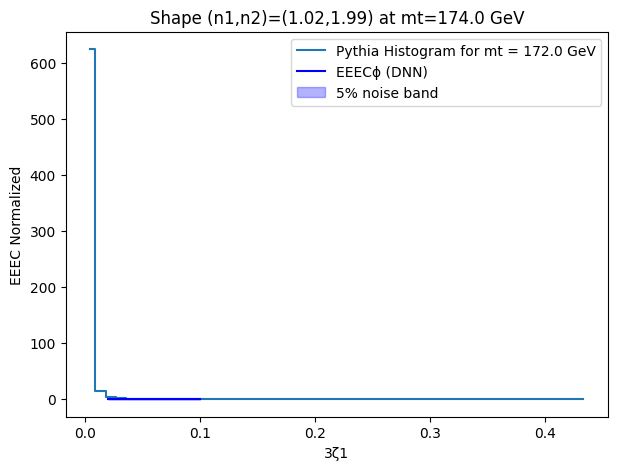

In [ ]:
n1 = 1.02
n2 = 1.99
delta_a = 0.01

#from DNN
zeta1_vals, eeec_vals = EEEC_curve(n1, n2, mt_true, model_test)

#generate 250 noisy replicas:
replicas = []
for _ in range(250):
    noisy = eeec_vals *( 1 + np.random.normal(0, 0.05, len(eeec_vals)))
    replicas.append(noisy)
replicas = np.array(replicas)

mean_shape = replicas.mean(axis=0)
lb = np.percentile(replicas, 2.5, axis=0)
ub = np.percentile(replicas, 97.5, axis=0)

x_axis = 3*zeta1_vals

#from PYTHIA
# Load raw data for mt=172.5:
data_test = np.loadtxt("Paper/dataset_172.5.txt")
zeta1, zeta2, zeta3 = data_test[:,0], data_test[:,1], data_test[:,2]
E_tilde = data_test[:,3]
mt = torch.tensor([172.0]*len(data_test))
# Apply shape filter
shape_mask = ((np.abs(zeta2 - n1*zeta1) < delta_a) & (np.abs(zeta3 - n2*zeta1) < delta_a))

# selected z1 values
z1_sel = zeta1[shape_mask]
# selected EEEC weights
E_sel = E_tilde[shape_mask]

bins = np.linspace(z1_sel.min(), z1_sel.max(), 50)
centers = 0.5*(bins[:-1] + bins[1:])
eeec_mc = np.zeros(len(centers))

for i in range(len(centers)):
    mask_bin = ((z1_sel >= bins[i]) &(z1_sel < bins[i+1]))
    eeec_mc[i] = E_sel[mask_bin].sum()

eeec_mc /= np.trapezoid(eeec_mc, centers)

plt.figure(figsize=(7,5))

plt.step(3*centers,eeec_mc,where='mid',
    label=f'Pythia Histogram for mt = {mt[0]} GeV')
plt.plot(x_axis, mean_shape,
         label="EEECϕ (DNN)", color='blue')
plt.fill_between(x_axis, lb, ub,
                 alpha=0.3, color='blue', label="5% noise band")
plt.xlabel("3ζ1")
plt.ylabel("EEEC Normalized")
plt.title(f"Shape (n1,n2)=({n1},{n2}) at mt={mt_true} GeV")
plt.legend()
plt.show()

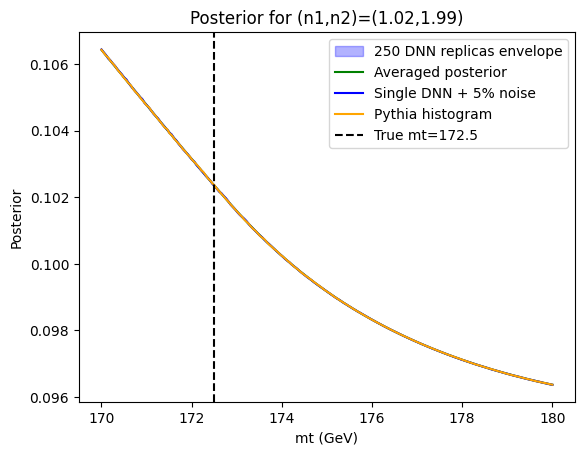

In [ ]:
#I think I have to atp create a function for getting posterior
def get_posterior(model, shape, n1, n2, mt_grid):

  posteriors = []
  for m in mt_grid:
    # Preprocessing:
    mt_norm = (m - mt_grid[0]) / (mt_grid[-1] - mt_grid[0])
    n1_log  = np.log(n1)
    n2_log  = np.log(n2)

    # Convert to tensors [1, 1]:
    mt_t = torch.tensor([[mt_norm]], dtype=torch.float32).to(device)
    n1_t = torch.tensor([[n1_log]],  dtype=torch.float32).to(device)
    n2_t = torch.tensor([[n2_log]],  dtype=torch.float32).to(device)

    with torch.no_grad():
        f = model_test_NRE(shape_t, mt_t, n1_t, n2_t)

    posteriors.append(torch.exp(f).item())

  #normalize
  posteriors = np.array(posteriors)
  norm = np.trapezoid(posteriors, mt_grid)
  if norm > 0:
    posteriors /= norm

  return posteriors

#parameters
mt_grid = np.linspace(170, 180, 200)
n1, n2 = 1.02, 1.99
mt_true = 172.5

#250 DNN replicas(just like before)
#getting EEEC shape from NRE and adding noise
_,eeec_vals = EEEC_curve(n1,n2,mt_true,model_test)
replicas_posterior = []
for _ in range(250):
  noisy = eeec_vals *( 1 + np.random.normal(0, 0.05, len(eeec_vals)))
  post = get_posterior(model_test_NRE, noisy, n1, n2, mt_grid)
  replicas_posterior.append(post)

replicas_posterior = np.array(replicas_posterior)
mean_post  = replicas_posterior.mean(axis=0)
lp = np.percentile(replicas_posterior, 2.5,  axis=0)
up = np.percentile(replicas_posterior, 97.5, axis=0)

#single DNN shape posterior
_,shape_single = EEEC_curve(n1,n2,mt_p,model_test)
noisy_single = shape_single *( 1 + np.random.normal(0, 0.05, len(shape_single)))
post_single = get_posterior(model_test_NRE, noisy_single, n1, n2, mt_grid)

#pythia posterior
post_pythia = get_posterior(model_test_NRE, eeec_mc, n1, n2, mt_grid)

# Plot:
plt.figure()
plt.fill_between(mt_grid, lp, up,
                 alpha=0.3, color='blue', label="250 DNN replicas envelope")
plt.plot(mt_grid, mean_post,
         color='green', label="Averaged posterior")
plt.plot(mt_grid, post_single,
         color='blue', label="Single DNN + 5% noise")
plt.plot(mt_grid, post_pythia,
         color='orange', label="Pythia histogram")

plt.axvline(mt_true, color='k', linestyle='--', label=f"True mt={mt_true}")

plt.xlabel("mt (GeV)")
plt.ylabel("Posterior")
plt.title(f"Posterior for (n1,n2)=({n1},{n2})")
plt.legend()
plt.show()